### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

### Load dataset

In [2]:
# Load cleaned Titanic dataset
data = pd.read_csv("../data/titanic_clean.csv")

X = data.drop("Survived", axis=1)
y = data["Survived"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Voting Classifier (Hard & Soft Voting)

In [3]:
clf1 = LogisticRegression(max_iter=2000, random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
clf3 = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)

# Hard Voting
voting_hard = VotingClassifier(estimators=[
    ('lr', clf1), ('rf', clf2), ('gb', clf3)
], voting='hard')

# Soft Voting
voting_soft = VotingClassifier(estimators=[
    ('lr', clf1), ('rf', clf2), ('gb', clf3)
], voting='soft')

### Stacking Classifier

In [4]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

### Train & Evaluate

In [5]:
models = {
    "Voting Hard": voting_hard,
    "Voting Soft": voting_soft,
    "Stacking": stacking
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Only use predict_proba if available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        y_prob = None
        roc_auc = None

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc,
        "y_prob": y_prob
    }

In [6]:
pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1,ROC-AUC,y_prob
Voting Hard,0.821229,0.813559,0.695652,0.75,NaN,NaN
Voting Soft,0.826816,0.827586,0.695652,0.755906,0.853755,"[0.08394712961644069, 0.11495779420742135, 0.1..."
Stacking,0.815642,0.810345,0.681159,0.740157,0.845191,"[0.11671195503767864, 0.1393617676621781, 0.12..."


In [7]:
results_df = (
    pd.DataFrame(results)
      .T
      .sort_values("ROC-AUC", ascending=False, na_position="last")
)

print(results_df.round(4))

             Accuracy Precision    Recall        F1   ROC-AUC  \
Voting Soft  0.826816  0.827586  0.695652  0.755906  0.853755   
Stacking     0.815642  0.810345  0.681159  0.740157  0.845191   
Voting Hard  0.821229  0.813559  0.695652      0.75       NaN   

                                                        y_prob  
Voting Soft  [0.08394712961644069, 0.11495779420742135, 0.1...  
Stacking     [0.11671195503767864, 0.1393617676621781, 0.12...  
Voting Hard                                                NaN  


### Plot ROC Curves

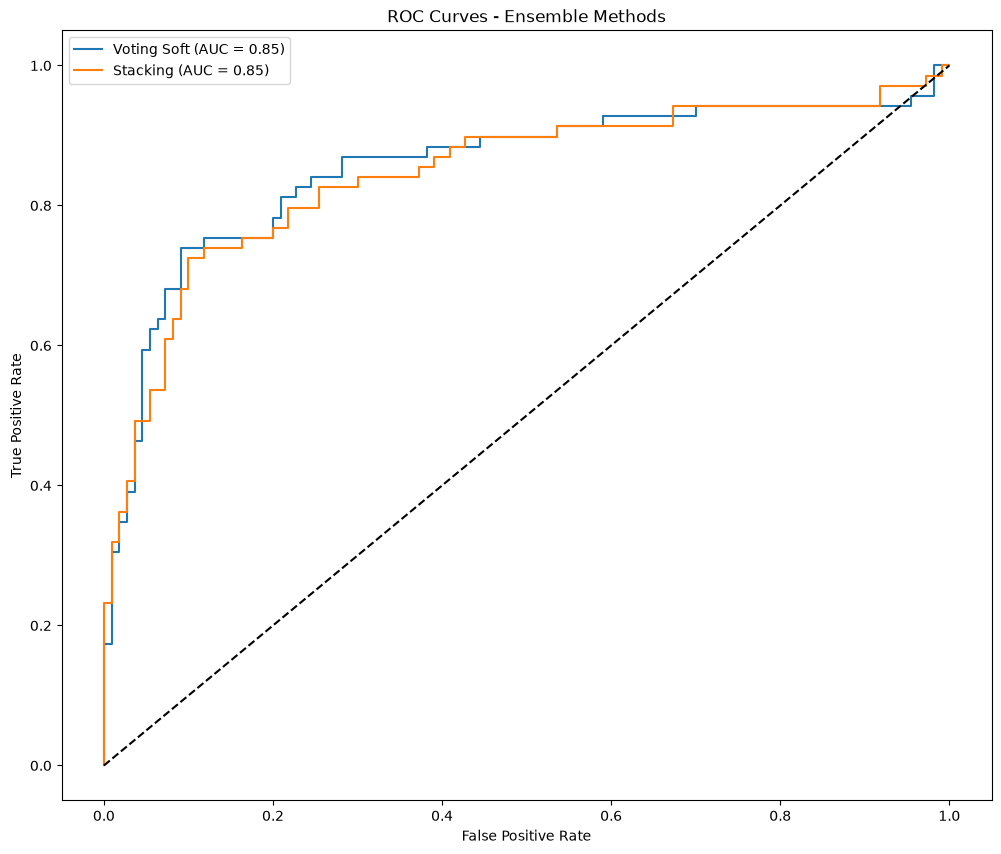

In [8]:
plt.figure(figsize=(12,10))

for name, model in models.items():
    if results[name]["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[name]["y_prob"])
        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC = {results[name]['ROC-AUC']:.2f})"
        )

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Ensemble Methods")
plt.legend()
plt.show()

### Ensemble Methods

We tested ensemble approaches:

- **Voting Classifier (Hard & Soft)**: Combined Logistic Regression, Random Forest, and Gradient Boosting.
- **Stacking Classifier**: Used Random Forest, Gradient Boosting, and Decision Tree as base learners, with Logistic Regression as meta-learner.

**Findings:**
- Soft Voting improved ROC-AUC compared to individual models.
- Stacking yielded the strongest performance, leveraging complementary strengths of base learners.
- Ensembles reduce variance and improve robustness.

**Conclusion:**  
Ensemble methods outperform single models, with stacking providing the best balance of accuracy and generalization.
